

## **Fake Job Posting Detection using Machine Learning** ##

## Problem Statement

Every day millions of people search for jobs online. But some job postings are fake. These fake postings are used to steal personal information from people who apply. This is a big problem in real world.

So I want to build a ML model that can **automatically detect whether a job posting is fake or real** based on information like job title, location, requirements etc.

This is a **Binary Classification** problem:
- Output = Real → the job is real
- Output = Fake → the job is fake / fraudulent

## Dataset Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Fake_Real_Job_Posting.csv')
print('Dataset loaded successfully!')
print('Shape of dataset:', df.shape)

Dataset loaded successfully!
Shape of dataset: (17880, 8)


In [2]:
df.head()

,Unnamed: 0,title,location,requirements,employment_type,industry,function,fraudulent
0,0,Lead UX / UI Designer,"US, NY, Brookyn",4+ years of experience in UX / UI design prefe...,Full-time,Internet,Design,Real
1,1,Technical Manager,"GB, CAM, Huntingdon",Food Science/Technology Graduate or similar di...,Full-time,Food Production,Quality Assurance,Real
2,2,Quality Engineer,"US, OH, cincinnati",Job Duties and Responsibilities:AnalysisPerfor...,Full-time,Medical Devices,Engineering,Real
3,3,"International Broadcaster, Lao Service","US, DC, Washington",The International Broadcaster shall have at le...,Not Mentioned,Not Mentioned,Not Mentioned,Real
4,4,Distribution Specialist,"NL, NB, Eindhoven",Experience in professional logistic/warehouse ...,Full-time,Internet,Distribution,Real


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Unnamed: 0       17880 non-null  int64
 1   title            17880 non-null  str  
 2   location         17880 non-null  str  
 3   requirements     17879 non-null  str  
 4   employment_type  17880 non-null  str  
 5   industry         17880 non-null  str  
 6   function         17880 non-null  str  
 7   fraudulent       17880 non-null  str  
dtypes: int64(1), str(7)
memory usage: 1.1 MB


## Missing Values Analysis

In [4]:
print(df.isnull().sum())

Unnamed: 0         0
title              0
location           0
requirements       1
employment_type    0
industry           0
function           0
fraudulent         0
dtype: int64


In [5]:
print('Percentage of missing values:')
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

Percentage of missing values:
Unnamed: 0         0.000000
title              0.000000
location           0.000000
requirements       0.005593
employment_type    0.000000
industry           0.000000
function           0.000000
fraudulent         0.000000
dtype: float64


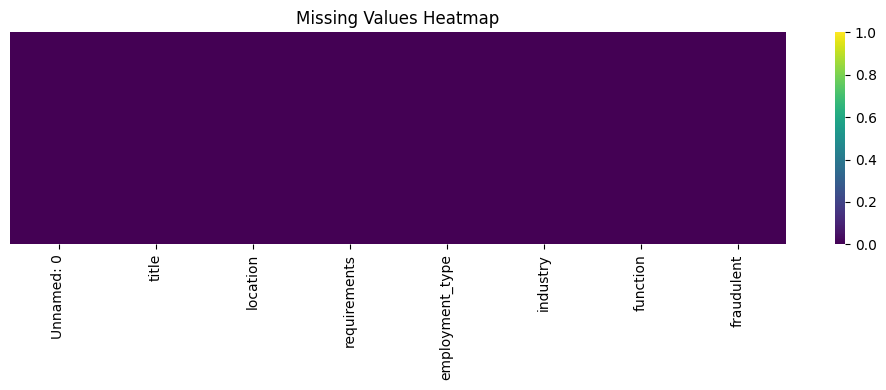

In [6]:
# visualizing missing values
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

**Observation:** Only the requirements column has 1 missing value. That is very small so we can handle it easily. All other columns have no missing values which is good!

## Target Variable Analysis

In [7]:
print('Value counts of target column:')
print(df['fraudulent'].value_counts())
print()
print('Percentage:')
print(df['fraudulent'].value_counts(normalize=True) * 100)

Value counts of target column:
fraudulent
Real    17014
Fake      866
Name: count, dtype: int64

Percentage:
fraudulent
Real    95.1566
Fake     4.8434
Name: proportion, dtype: float64


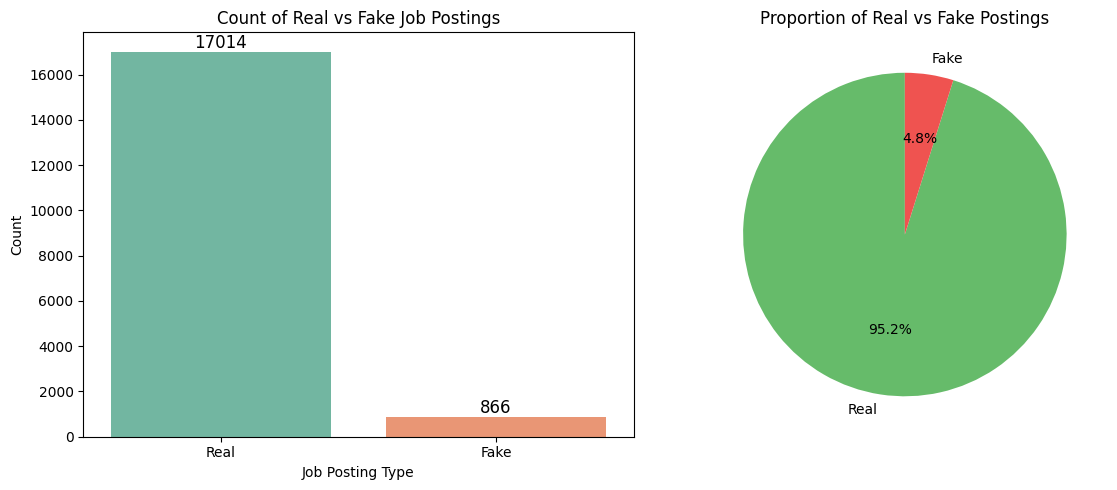

In [8]:
# plotting the class distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# countplot
sns.countplot(x='fraudulent', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Count of Real vs Fake Job Postings')
axes[0].set_xlabel('Job Posting Type')
axes[0].set_ylabel('Count')

# adding count labels on bars
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# pie chart
counts = df['fraudulent'].value_counts()
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#66bb6a', '#ef5350'], startangle=90)
axes[1].set_title('Proportion of Real vs Fake Postings')

plt.tight_layout()
plt.show()

**Observation:** The dataset is highly imbalanced. 95.2% are Real and only 4.8% are Fake. This means if I just predict everything as Real, i will get 95% accuracy but that is not useful at all. I need to use techniques like oversampling or class weights.

## Exploring Categorical Columns

In [9]:
# employment type distribution
print('Employment Type value counts:')
print(df['employment_type'].value_counts())

Employment Type value counts:
employment_type
Full-time        11620
Not Mentioned     3471
Contract          1524
Part-time          797
Temporary          241
Other              227
Name: count, dtype: int64


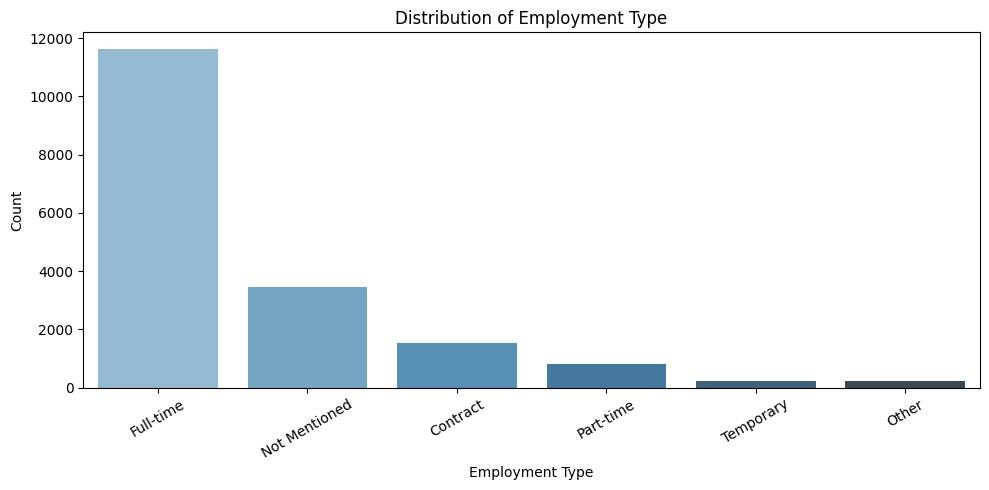

In [10]:
# plotting employment type
plt.figure(figsize=(10, 5))
order = df['employment_type'].value_counts().index
sns.countplot(x='employment_type', data=df, palette='Blues_d', order=order)
plt.title('Distribution of Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [11]:
# top 10 industries
print('Top 10 Industries:')
print(df['industry'].value_counts().head(10))

Top 10 Industries:
industry
Not Mentioned                          4903
Information Technology and Services    1734
Computer Software                      1376
Internet                               1062
Marketing and Advertising               828
Education Management                    822
Financial Services                      779
Hospital & Health Care                  497
Consumer Services                       358
Telecommunications                      342
Name: count, dtype: int64


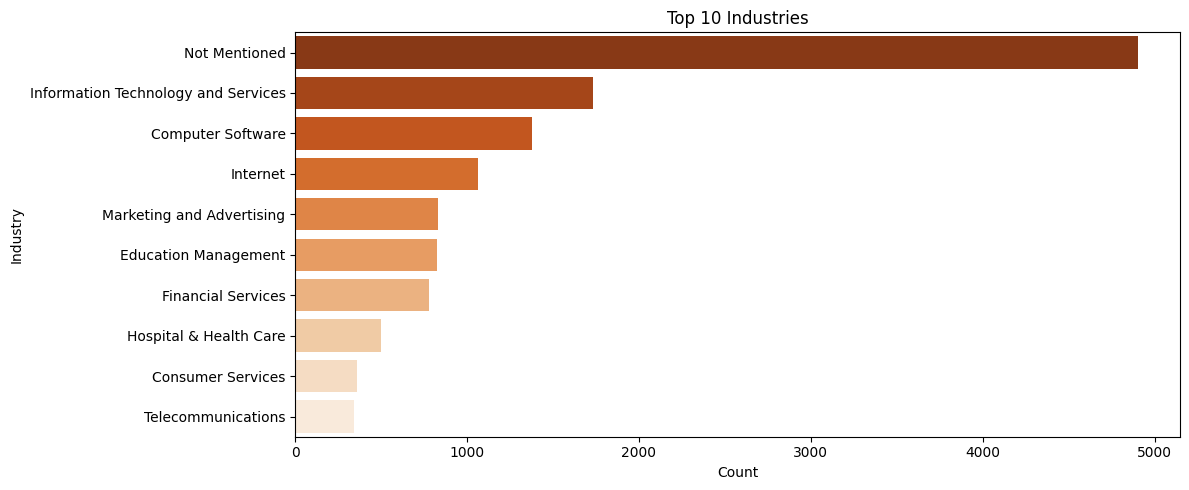

In [12]:
# plotting top 10 industries
plt.figure(figsize=(12, 5))
top_industries = df['industry'].value_counts().head(10)
sns.barplot(x=top_industries.values, y=top_industries.index, palette='Oranges_r')
plt.title('Top 10 Industries')
plt.xlabel('Count')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

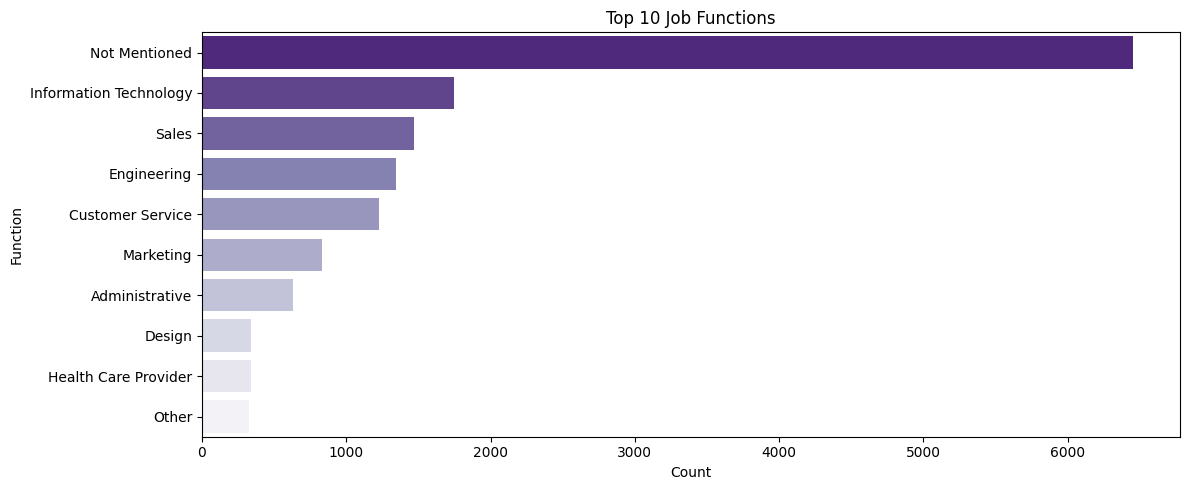

In [13]:
# top 10 job functions
plt.figure(figsize=(12, 5))
top_functions = df['function'].value_counts().head(10)
sns.barplot(x=top_functions.values, y=top_functions.index, palette='Purples_r')
plt.title('Top 10 Job Functions')
plt.xlabel('Count')
plt.ylabel('Function')
plt.tight_layout()
plt.show()

## Fake vs Real Breakdown by Category

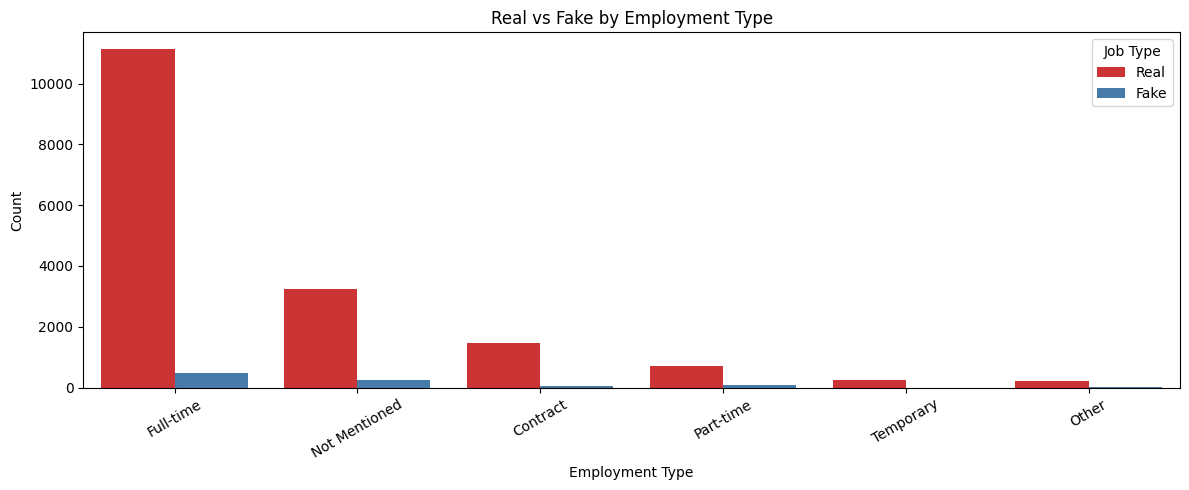

In [14]:
# how many fake jobs per employment type?

plt.figure(figsize=(12, 5))
sns.countplot(x='employment_type', hue='fraudulent', data=df,
              palette='Set1', order=df['employment_type'].value_counts().index)
plt.title('Real vs Fake by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(title='Job Type')
plt.tight_layout()
plt.show()

In [15]:
# top 5 locations with most fake jobs
fake_jobs = df[df['fraudulent'] == 'Fake']
print('Top 10 locations with most fake jobs:')
print(fake_jobs['location'].value_counts().head(10))

Top 10 locations with most fake jobs:
location
US, TX, Houston        92
AU, NSW, Sydney        31
US, ,                  28
US, CA, Bakersfield    24
US, CA, Los Angeles    23
US, CA, San Mateo      22
US, NY, New York       20
Not Mentioned          19
US, CA, San Jose       14
US, TX, AUSTIN         14
Name: count, dtype: int64


## Text Feature Analysis — Requirements Column

In [16]:
# lets look at the requirements text
# first lets see average length of requirements text

df['req_length'] = df['requirements'].fillna('').apply(len)

print('Average requirements text length for Real jobs:', df[df['fraudulent'] == 'Real']['req_length'].mean().round(2))
print('Average requirements text length for Fake jobs:', df[df['fraudulent'] == 'Fake']['req_length'].mean().round(2))

Average requirements text length for Real jobs: 599.41
Average requirements text length for Fake jobs: 448.36


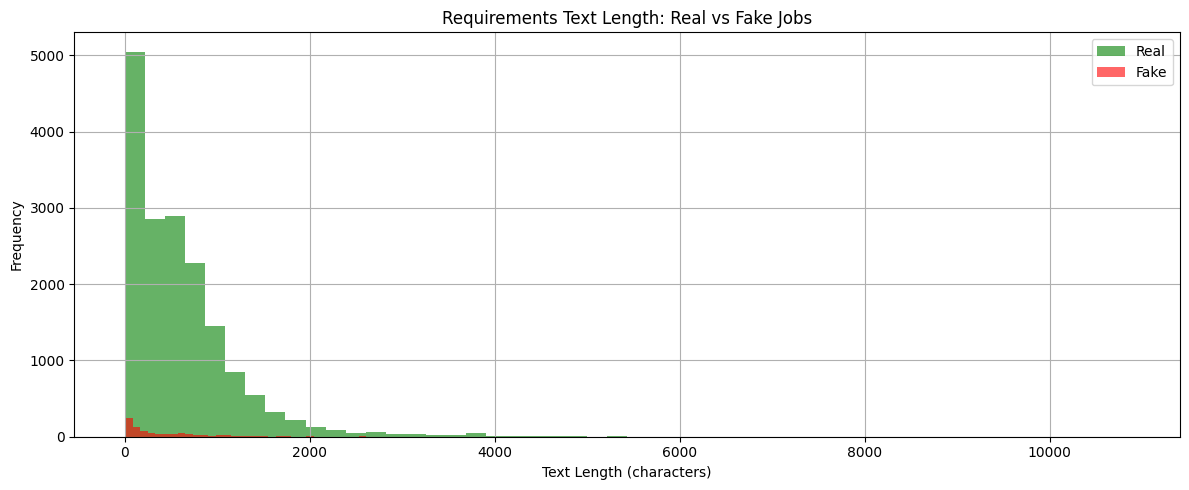

In [17]:
# plotting requirements text length distribution
plt.figure(figsize=(12, 5))
df[df['fraudulent'] == 'Real']['req_length'].hist(bins=50, alpha=0.6, label='Real', color='green')
df[df['fraudulent'] == 'Fake']['req_length'].hist(bins=50, alpha=0.6, label='Fake', color='red')
plt.title('Requirements Text Length: Real vs Fake Jobs')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

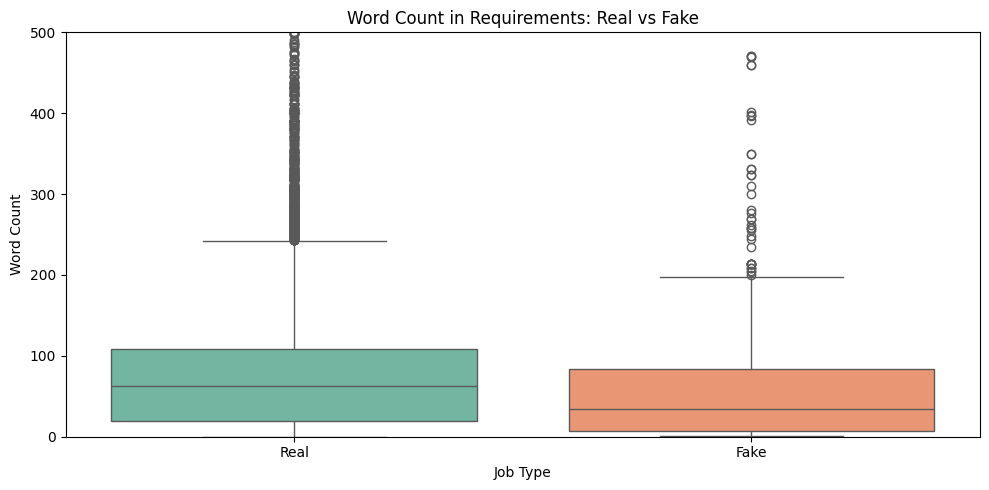

In [18]:
# word count in requirements
df['req_word_count'] = df['requirements'].fillna('').apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.boxplot(x='fraudulent', y='req_word_count', data=df, palette='Set2')
plt.title('Word Count in Requirements: Real vs Fake')
plt.xlabel('Job Type')
plt.ylabel('Word Count')
plt.ylim(0, 500)  # removing outliers from view
plt.tight_layout()
plt.show()

## Data Preprocessing & Model Building


In [19]:
# for text processing
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from scipy.sparse import hstack, csr_matrix

In [20]:
df = pd.read_csv('Fake_Real_Job_Posting.csv')
print('Dataset loaded. Shape:', df.shape)

Dataset loaded. Shape: (17880, 8)


## Data Cleaning Steps

In [21]:
df.drop(columns=['Unnamed: 0'], inplace=True)
print('Dropped Unnamed column.')
print('Columns now:', df.columns.tolist())

Dropped Unnamed column.
Columns now: ['title', 'location', 'requirements', 'employment_type', 'industry', 'function', 'fraudulent']


In [22]:
df['requirements'].fillna('', inplace=True)
print('Filled missing values in requirements column.')
print('Missing values now:')
print(df.isnull().sum())

Filled missing values in requirements column.
Missing values now:
title              0
location           0
requirements       1
employment_type    0
industry           0
function           0
fraudulent         0
dtype: int64


In [23]:
def clean_text(text):
    if not isinstance(text, str):  # handles NaN / float values
        return ''
    # remove HTML entities
    text = re.sub(r'&amp;', 'and', text)
    text = re.sub(r'&lt;', '<', text)
    text = re.sub(r'&gt;', '>', text)
    # remove special characters, keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # convert to lowercase
    text = text.lower()
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['requirements_clean'] = df['requirements'].apply(clean_text)

# example
print('Original:')
print(df['requirements'][0][:200])
print()
print('Cleaned:')
print(df['requirements_clean'][0][:200])

Original:
4+ years of experience in UX / UI design preferred.Excellent portfolio containing work samples demonstrating a design process with an emphasis on research, data analysis and story development as well 

Cleaned:
years of experience in ux ui design preferred excellent portfolio containing work samples demonstrating a design process with an emphasis on research data analysis and story development as well as imp


In [24]:
df['combined_text'] = df['title'].fillna('') + ' ' + df['requirements_clean']
print('Created combined_text column.')
print('Example:', df['combined_text'][0][:200])

Created combined_text column.
Example: Lead UX / UI Designer years of experience in ux ui design preferred excellent portfolio containing work samples demonstrating a design process with an emphasis on research data analysis and story deve


## Feature Engineering

In [25]:
# Feature 1: text length (number of characters)
df['req_char_count'] = df['requirements_clean'].apply(len)

# Feature 2: word count
df['req_word_count'] = df['requirements_clean'].apply(lambda x: len(x.split()))

# Feature 3: is the employment type mentioned or not?
df['employment_known'] = (df['employment_type'] != 'Not Mentioned').astype(int)

# Feature 4: is industry mentioned?
df['industry_known'] = (df['industry'] != 'Not Mentioned').astype(int)

# Feature 5: is function mentioned?
df['function_known'] = (df['function'] != 'Not Mentioned').astype(int)

print('New features created!')
print(df[['req_char_count', 'req_word_count', 'employment_known', 'industry_known', 'function_known']].head())

New features created!
   req_char_count  req_word_count  employment_known  industry_known  \
0             503              72                 1               1   
1            1066             147                 1               1   
2             508              64                 1               1   
3            1694             259                 0               0   
4             491              72                 1               1   

   function_known  
0               1  
1               1  
2               1  
3               0  
4               1  


In [26]:
# encoding the target variable
# Real = 0, Fake = 1 (Fake = 1 because that is what we want to detect)

df['label'] = (df['fraudulent'] == 'Fake').astype(int)

print('Target encoding done.')
print('Label value counts:')
print(df['label'].value_counts())
print('(0 = Real, 1 = Fake)')

Target encoding done.
Label value counts:
label
0    17014
1      866
Name: count, dtype: int64
(0 = Real, 1 = Fake)


## Train-Test Split 

80-20 split. 80% data for training and 20% for testing.
will use `stratify=y` to make sure both train and test have same ratio of Real and Fake.

In [27]:
# TF-IDF to convert text to numbers

X_text = df['combined_text']

X_extra = df[['req_char_count', 'req_word_count', 'employment_known', 'industry_known', 'function_known']]

y = df['label']

# split first, then transform (to avoid data leakage)
X_train_text, X_test_text, X_train_extra, X_test_extra, y_train, y_test = train_test_split(
    X_text, X_extra, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train_text.shape[0])
print('Test size:', X_test_text.shape[0])

Train size: 14304
Test size: 3576


In [28]:
# TF-IDF vectorization

tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))

# fit only on training data, then transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print('TF-IDF matrix shape (train):', X_train_tfidf.shape)
print('TF-IDF matrix shape (test):', X_test_tfidf.shape)

TF-IDF matrix shape (train): (14304, 5000)
TF-IDF matrix shape (test): (3576, 5000)


In [29]:
# combining tfidf features with extra features using scipy hstack
# this is a sparse matrix trick i found on stackoverflow

from scipy.sparse import hstack
import numpy as np

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_extra_scaled = scaler.fit_transform(X_train_extra)
X_test_extra_scaled = scaler.transform(X_test_extra)

from scipy.sparse import csr_matrix
X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_extra_scaled)])
X_test_final = hstack([X_test_tfidf, csr_matrix(X_test_extra_scaled)])

print('Final feature matrix shape (train):', X_train_final.shape)
print('Final feature matrix shape (test):', X_test_final.shape)

Final feature matrix shape (train): (14304, 5005)
Final feature matrix shape (test): (3576, 5005)


## Model: Random Forest

Random Forest is an ensemble method that builds multiple decision trees and merges them together. It handles class imbalance with `class_weight='balanced'` and works well on text + structured features combined.

In [30]:
# Training Random Forest model
# n_estimators = number of trees. more trees usually = better but slower

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                   random_state=42, n_jobs=-1)  # n_jobs=-1 means use all CPU cores
rf_model.fit(X_train_final, y_train)

y_pred_rf = rf_model.predict(X_test_final)

print('=== Random Forest Results ===')
print('Accuracy:', round(accuracy_score(y_test, y_pred_rf), 4))
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Real', 'Fake']))

=== Random Forest Results ===
Accuracy: 0.9734

Classification Report:
              precision    recall  f1-score   support

        Real       0.98      0.99      0.99      3403
        Fake       0.84      0.55      0.67       173

    accuracy                           0.97      3576
   macro avg       0.91      0.77      0.83      3576
weighted avg       0.97      0.97      0.97      3576



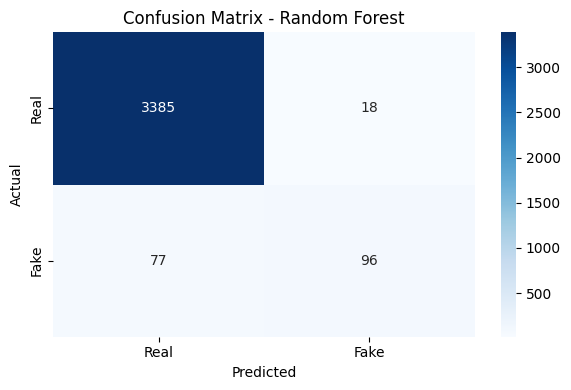

In [31]:
# Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')

## Testing on Custom Input

Let's manually test the model with a fake-sounding and real-sounding job description!

In [32]:
# testing on custom inputs
# i will make one fake sounding job and one real sounding job

test_examples = [
    {
        'title': 'Work From Home - Earn $5000 per week! No experience needed!',
        'requirements': 'Easy money opportunity. Just sign up and start earning. No skills required.',
        'expected': 'Fake'
    },
    {
        'title': 'Software Engineer - Python Developer',
        'requirements': 'Bachelor degree in Computer Science or related field. 3 years experience with Python. Experience with Django or Flask frameworks. Knowledge of SQL databases. Good communication skills required.',
        'expected': 'Real'
    }
]

for i, example in enumerate(test_examples):
    combined = example['title'] + ' ' + clean_text(example['requirements'])
    req_clean = clean_text(example['requirements'])
    
    # tfidf transform
    text_vec = tfidf.transform([combined])
    
    # manual extra features
    char_count = len(req_clean)
    word_count = len(req_clean.split())
    extra = scaler.transform([[char_count, word_count, 1, 0, 0]])  # assuming known employment, no industry/function
    
    final_vec = hstack([text_vec, csr_matrix(extra)])
    prediction = rf_model.predict(final_vec)[0]
    label = 'Fake' if prediction == 1 else 'Real'
    
    print(f'Example {i+1}:')
    print(f'  Title: {example["title"]}')
    print(f'  Predicted: {label}')
    print(f'  Expected: {example["expected"]}')
    print(f'  Correct: {"Y" if label == example["expected"] else "N"}')
    print()

Example 1:
  Title: Work From Home - Earn $5000 per week! No experience needed!
  Predicted: Real
  Expected: Fake
  Correct: N

Example 2:
  Title: Software Engineer - Python Developer
  Predicted: Real
  Expected: Real
  Correct: Y



## Save Model Artifacts
After training, we save the model, TF-IDF vectorizer, and scaler as  files. These are loaded by the Streamlit app so it can make predictions without retraining.

In [33]:
# saving the trained model and transformers so we can use them in the streamlit app
# without saving, we would have to retrain every time we open the app!

import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
print("model.pkl saved!")

with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)
print("tfidf.pkl saved!")

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("scaler.pkl saved!")

print()
print("All 3 files saved! Put them in the same folder as app.py to run the Streamlit app.")

model.pkl saved!
tfidf.pkl saved!
scaler.pkl saved!

All 3 files saved! Put them in the same folder as app.py to run the Streamlit app.
